In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [3]:
import zipfile

with zipfile.ZipFile("mnist_train.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Training file extracted successfully!")

Training file extracted successfully!


In [4]:
import zipfile

with zipfile.ZipFile("mnist_test.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Testing file extracted successfully!")

Testing file extracted successfully!


In [5]:
import os

os.listdir()

['.config',
 'mnist_train.csv',
 'mnist_train.csv.zip',
 'mnist_test.csv',
 'mnist_test.csv.zip',
 'sample_data']

In [6]:
import pandas as pd

df = pd.read_csv("mnist_train.csv")

df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print("Input Features:")

print(df.columns[1:])

print()

print("Target Variable:")

print(df.columns[0])

Input Features:
Index(['1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=784)

Target Variable:
label


In [8]:
print("Dataset Shape:")

print(df.shape)

Dataset Shape:
(60000, 785)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


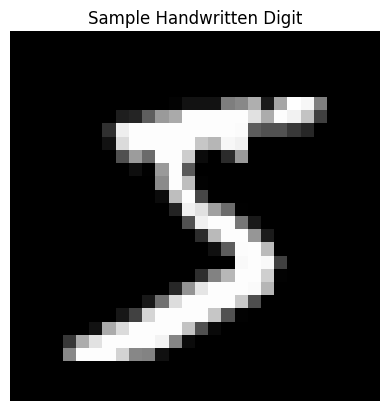

Label: 5


In [10]:
image = df.iloc[0,1:].values.reshape(28,28)

plt.imshow(image, cmap="gray")

plt.title("Sample Handwritten Digit")

plt.axis("off")

plt.show()

print("Label:", df.iloc[0,0])

In [11]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [12]:
X = df.iloc[:,1:]

y = df.iloc[:,0]

print(X.shape)

print(y.shape)

(60000, 784)
(60000,)


In [13]:
X = X / 255.0

X.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(48000, 784)
(12000, 784)


In [15]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

print(y_train.shape)

print(y_test.shape)

(48000, 10)
(12000, 10)


In [16]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9157 - loss: 0.2889 - val_accuracy: 0.9445 - val_loss: 0.1779
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9628 - loss: 0.1209 - val_accuracy: 0.9600 - val_loss: 0.1263
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9753 - loss: 0.0836 - val_accuracy: 0.9657 - val_loss: 0.1081
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9799 - loss: 0.0645 - val_accuracy: 0.9720 - val_loss: 0.0907
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9857 - loss: 0.0465 - val_accuracy: 0.9731 - val_loss: 0.0959
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9882 - loss: 0.0364 - val_accuracy: 0.9744 - val_loss: 0.0852
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9901 - loss: 0.0308 - val_accuracy: 0.9719 - val_loss: 0.1028
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9915 - loss: 0.0260 - 

In [19]:
# Predict the handwritten digits

y_pred = model.predict(X_test)

# Convert predictions to class labels

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9744 - loss: 0.1169
Test Accuracy: 0.9744166731834412


In [21]:
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[1171    0    0    0    1    0    0    0    2    1]
 [   0 1302    6    2    2    0    6    0    1    3]
 [   7    5 1135    6    2    0    1   10    6    2]
 [   4    0   11 1174    0    7    1    4   10    8]
 [   3    0    0    1 1152    0    0    1    0   19]
 [  14    0    1   16    5 1041   11    3    9    4]
 [   9    1    0    0    4    0 1161    0    2    0]
 [   1    1    7    1    4    0    0 1264    3   18]
 [   8    3    4    4    5    4    4    1 1124    3]
 [   5    0    0    0    8    2    2    6    2 1169]]


In [22]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1175
           1       0.99      0.98      0.99      1322
           2       0.98      0.97      0.97      1174
           3       0.98      0.96      0.97      1219
           4       0.97      0.98      0.98      1176
           5       0.99      0.94      0.96      1104
           6       0.98      0.99      0.98      1177
           7       0.98      0.97      0.98      1299
           8       0.97      0.97      0.97      1160
           9       0.95      0.98      0.97      1194

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



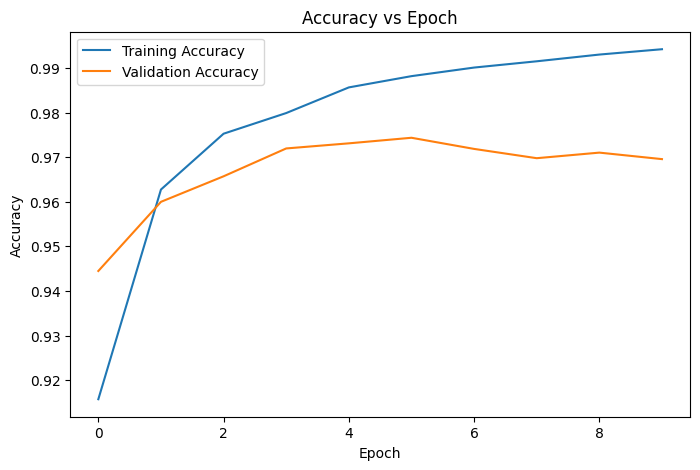

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

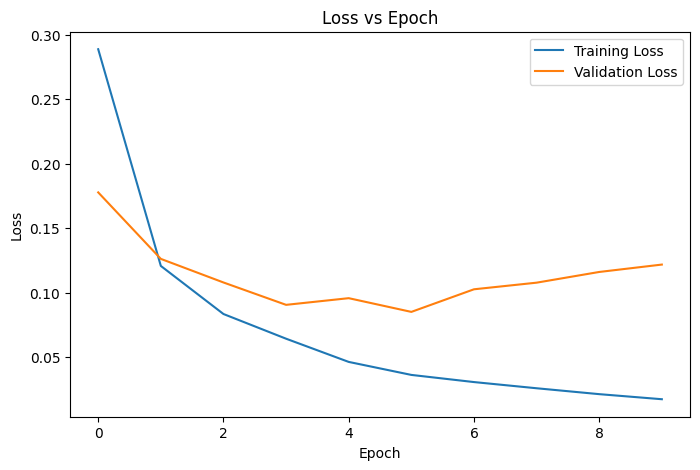

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Observations

1. The ANN model achieved a high test accuracy, showing that it can effectively recognize handwritten digits.

2. The confusion matrix indicates that most digits were classified correctly, with only a few misclassifications between visually similar digits.

3. The accuracy increased steadily while the loss decreased over the training epochs, indicating that the model learned effectively without significant overfitting.

4. The ANN successfully captured complex patterns in handwritten digit images, making it suitable for image classification tasks.

## Conclusion

An Artificial Neural Network (ANN) was developed to recognize handwritten digits using the MNIST dataset. The model successfully learned complex patterns from the pixel values and achieved high classification accuracy on the test dataset. The training and validation results showed steady improvement over the 10 epochs, demonstrating the effectiveness of the ANN architecture for image classification. The model correctly identified most handwritten digits, making it suitable for real-world applications such as postal code recognition, bank cheque processing, and document digitization. Although ANN requires significant computational resources and large amounts of training data, it remains one of the most powerful deep learning techniques for solving image recognition problems.

### Key Findings
- The ANN successfully classified handwritten digits (0–9) with high accuracy.
- The model effectively learned patterns from pixel values and correctly recognized most handwritten digits.
- The training accuracy increased while the loss decreased over the epochs, indicating successful learning.

### Importance of Hidden Layers in ANN
Hidden layers help the ANN learn complex and non-linear relationships within the input data. They automatically extract meaningful features from handwritten digit images, which significantly improves the model's classification performance.

### One Advantage of Deep Learning over Traditional Machine Learning
Deep Learning automatically learns important features directly from raw data, reducing the need for manual feature engineering and achieving better performance in image recognition tasks.

### One Limitation of ANN
A limitation of ANN is that it requires a large amount of training data and high computational resources, making the training process more time-consuming than many traditional machine learning algorithms.